# PPO for Continuous Robotics Control using HalfCheetah-v5


In [5]:
## Part 1: Install Dependencies
!pip -q install "gymnasium[mujoco]" torch matplotlib numpy pandas

Import Libraries

In [6]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("Gymnasium version:", gym.__version__)
print("PyTorch version:", torch.__version__)

Device: cpu
Gymnasium version: 1.3.0
PyTorch version: 2.11.0+cpu


Creating MujoCo Robotics Environment



In [7]:
ENV_NAME = "HalfCheetah-v5"

env = gym.make(ENV_NAME)

state, info = env.reset(seed=SEED)
env.action_space.seed(SEED)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

action_low = env.action_space.low.astype(np.float32)
action_high = env.action_space.high.astype(np.float32)

print("Environment:", ENV_NAME)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("State dimension:", state_dim)
print("Action dimension:", action_dim)
print("Action low:", action_low)
print("Action high:", action_high)
print("Initial state shape:", state.shape)

Environment: HalfCheetah-v5
Observation space: Box(-inf, inf, (17,), float64)
Action space: Box(-1.0, 1.0, (6,), float32)
State dimension: 17
Action dimension: 6
Action low: [-1. -1. -1. -1. -1. -1.]
Action high: [1. 1. 1. 1. 1. 1.]
Initial state shape: (17,)


# **Actor Critic Model**

In [8]:
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_size=64):
        super().__init__()

        self.actor = nn.Sequential(
            nn.Linear(state_dim, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, action_dim)
        )

        self.log_std = nn.Parameter(torch.zeros(action_dim))

        self.critic = nn.Sequential(
            nn.Linear(state_dim, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

    def get_distribution_and_value(self, states):
        mean = self.actor(states)
        std = torch.exp(self.log_std).expand_as(mean)
        dist = Normal(mean, std)
        value = self.critic(states).squeeze(-1)
        return dist, value

    def act(self, states):
        dist, value = self.get_distribution_and_value(states)
        raw_action = dist.sample()
        log_prob = dist.log_prob(raw_action).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1)
        return raw_action, log_prob, entropy, value

    def evaluate_actions(self, states, raw_actions):
        dist, values = self.get_distribution_and_value(states)
        log_probs = dist.log_prob(raw_actions).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1)
        return log_probs, entropy, values


model = ActorCritic(state_dim, action_dim).to(device)
print(model)

ActorCritic(
  (actor): Sequential(
    (0): Linear(in_features=17, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=6, bias=True)
  )
  (critic): Sequential(
    (0): Linear(in_features=17, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [9]:
action_low_t = torch.tensor(action_low, dtype=torch.float32, device=device)
action_high_t = torch.tensor(action_high, dtype=torch.float32, device=device)

def squash_action(raw_action):
    squashed = torch.tanh(raw_action)

    scaled = action_low_t + (squashed + 1.0) * 0.5 * (action_high_t - action_low_t)

    return scaled

# **Hyperparameters**

In [10]:
'''
LEARNING_RATE = float(input("Enter learning rate: "))
GAMMA = float(input("Enter gamma: "))
GAE_LAMBDA = float(input("Enter GAE lambda: "))
CLIP_EPSILON = float(input("Enter clip epsilon: "))

ROLLOUT_STEPS = int(input("Enter rollout steps: "))
BATCH_SIZE = int(input("Enter batch size: "))
PPO_EPOCHS = int(input("Enter PPO epochs: "))

VALUE_COEF = float(input("Enter value coefficient: "))
ENTROPY_COEF = float(input("Enter entropy coefficient: "))
MAX_GRAD_NORM = float(input("Enter max gradient norm: "))

NUM_UPDATES = int(input("Enter number of updates: "))
'''

LEARNING_RATE = 3e-4
GAMMA = 0.99
GAE_LAMBDA = 0.95
CLIP_EPSILON = 0.20

ROLLOUT_STEPS = 2048
BATCH_SIZE = 64
PPO_EPOCHS = 10

VALUE_COEF = 0.5
ENTROPY_COEF = 0.01
MAX_GRAD_NORM = 0.5

NUM_UPDATES = 100

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("Learning rate:", LEARNING_RATE)
print("Gamma:", GAMMA)
print("GAE lambda:", GAE_LAMBDA)
print("Clip epsilon:", CLIP_EPSILON)
print("Rollout steps:", ROLLOUT_STEPS)
print("Batch size:", BATCH_SIZE)
print("PPO epochs:", PPO_EPOCHS)

Learning rate: 0.0003
Gamma: 0.99
GAE lambda: 0.95
Clip epsilon: 0.2
Rollout steps: 2048
Batch size: 64
PPO epochs: 10


# **RollOut Buffer**

In [11]:
class RolloutBuffer:
    def __init__(self):
        self.states = []
        self.raw_actions = []
        self.rewards = []
        self.dones = []
        self.log_probs = []
        self.values = []

    def add(self, state, raw_action, reward, done, log_prob, value):
        self.states.append(np.asarray(state, dtype=np.float32))
        self.raw_actions.append(np.asarray(raw_action, dtype=np.float32))
        self.rewards.append(float(reward))
        self.dones.append(float(done))
        self.log_probs.append(float(log_prob))
        self.values.append(float(value))

    def clear(self):
        self.__init__()

## Generalized Advantage Estimation (GAE)


In [12]:
def compute_gae(rewards, values, dones, next_value, gamma=0.99, gae_lambda=0.95):
    rewards = np.asarray(rewards, dtype=np.float32)
    values = np.asarray(values, dtype=np.float32)
    dones = np.asarray(dones, dtype=np.float32)

    advantages = np.zeros_like(rewards, dtype=np.float32)

    gae = 0.0

    for t in reversed(range(len(rewards))):
        if t == len(rewards) - 1:
            next_val = next_value
        else:
            next_val = values[t + 1]

        non_terminal = 1.0 - dones[t]

        delta = rewards[t] + gamma * next_val * non_terminal - values[t]

        gae = delta + gamma * gae_lambda * non_terminal * gae

        advantages[t] = gae

    returns = advantages + values

    return advantages, returns

In [13]:
def ppo_update(model, optimizer, buffer, advantages, returns):
    states = torch.tensor(
        np.asarray(buffer.states),
        dtype=torch.float32,
        device=device
    )

    raw_actions = torch.tensor(
        np.asarray(buffer.raw_actions),
        dtype=torch.float32,
        device=device
    )

    old_log_probs = torch.tensor(
        np.asarray(buffer.log_probs),
        dtype=torch.float32,
        device=device
    )

    advantages = torch.tensor(
        advantages,
        dtype=torch.float32,
        device=device
    )

    returns = torch.tensor(
        returns,
        dtype=torch.float32,
        device=device
    )

    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    dataset_size = states.shape[0]

    policy_losses = []
    value_losses = []
    entropies = []
    approx_kls = []
    clip_fractions = []

    for _ in range(PPO_EPOCHS):
        indices = np.arange(dataset_size)
        np.random.shuffle(indices)

        for start in range(0, dataset_size, BATCH_SIZE):
            batch_idx = indices[start:start + BATCH_SIZE]

            batch_states = states[batch_idx]
            batch_actions = raw_actions[batch_idx]
            batch_old_log_probs = old_log_probs[batch_idx]
            batch_advantages = advantages[batch_idx]
            batch_returns = returns[batch_idx]

            new_log_probs, entropy, values = model.evaluate_actions(
                batch_states,
                batch_actions
            )

            log_ratio = new_log_probs - batch_old_log_probs
            ratio = torch.exp(log_ratio)

            surrogate1 = ratio * batch_advantages

            surrogate2 = torch.clamp(
                ratio,
                1.0 - CLIP_EPSILON,
                1.0 + CLIP_EPSILON
            ) * batch_advantages

            policy_loss = -torch.min(surrogate1, surrogate2).mean()

            value_loss = (batch_returns - values).pow(2).mean()

            entropy_mean = entropy.mean()

            loss = (
                policy_loss
                + VALUE_COEF * value_loss
                - ENTROPY_COEF * entropy_mean
            )

            optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                MAX_GRAD_NORM
            )

            optimizer.step()

            with torch.no_grad():
                approx_kl = ((ratio - 1.0) - log_ratio).mean().item()

                clip_fraction = (
                    (torch.abs(ratio - 1.0) > CLIP_EPSILON)
                    .float()
                    .mean()
                    .item()
                )

            policy_losses.append(policy_loss.item())
            value_losses.append(value_loss.item())
            entropies.append(entropy_mean.item())
            approx_kls.append(approx_kl)
            clip_fractions.append(clip_fraction)

    return {
        "policy_loss": float(np.mean(policy_losses)),
        "value_loss": float(np.mean(value_losses)),
        "entropy": float(np.mean(entropies)),
        "approx_kl": float(np.mean(approx_kls)),
        "clip_fraction": float(np.mean(clip_fractions)),
    }

# **Training**

In [14]:
episode_rewards = []

policy_loss_history = []
value_loss_history = []
entropy_history = []
approx_kl_history = []
clip_fraction_history = []
mean_reward_history = []

total_steps = 0
current_episode_reward = 0.0

state, info = env.reset(seed=SEED)

for update in range(NUM_UPDATES):

    buffer = RolloutBuffer()

    for _ in range(ROLLOUT_STEPS):

        state_tensor = torch.tensor(
            state,
            dtype=torch.float32,
            device=device
        ).unsqueeze(0)

        with torch.no_grad():
            raw_action_t, log_prob_t, _, value_t = model.act(state_tensor)

            env_action_t = squash_action(raw_action_t)

        raw_action = raw_action_t.squeeze(0).cpu().numpy()
        env_action = env_action_t.squeeze(0).cpu().numpy()

        next_state, reward, terminated, truncated, info = env.step(env_action)

        done = terminated or truncated

        buffer.add(
            state=state,
            raw_action=raw_action,
            reward=reward,
            done=done,
            log_prob=log_prob_t.item(),
            value=value_t.item()
        )

        total_steps += 1
        current_episode_reward += reward

        state = next_state

        if done:
            episode_rewards.append(current_episode_reward)

            current_episode_reward = 0.0

            state, info = env.reset()

    final_state_tensor = torch.tensor(
        state,
        dtype=torch.float32,
        device=device
    ).unsqueeze(0)

    with torch.no_grad():
        _, final_value = model.get_distribution_and_value(final_state_tensor)
        next_value = final_value.item()

    advantages, returns = compute_gae(
        rewards=buffer.rewards,
        values=buffer.values,
        dones=buffer.dones,
        next_value=next_value,
        gamma=GAMMA,
        gae_lambda=GAE_LAMBDA
    )

    metrics = ppo_update(
        model=model,
        optimizer=optimizer,
        buffer=buffer,
        advantages=advantages,
        returns=returns
    )

    policy_loss_history.append(metrics["policy_loss"])
    value_loss_history.append(metrics["value_loss"])
    entropy_history.append(metrics["entropy"])
    approx_kl_history.append(metrics["approx_kl"])
    clip_fraction_history.append(metrics["clip_fraction"])

    recent_reward = (
        float(np.mean(episode_rewards[-10:]))
        if len(episode_rewards) > 0
        else 0.0
    )

    mean_reward_history.append(recent_reward)

    print(
        f"Update {update + 1:03d}/{NUM_UPDATES} | "
        f"Steps {total_steps:07d} | "
        f"Episodes {len(episode_rewards):04d} | "
        f"Recent Reward {recent_reward:9.2f} | "
        f"Policy Loss {metrics['policy_loss']:8.4f} | "
        f"Value Loss {metrics['value_loss']:10.4f} | "
        f"Entropy {metrics['entropy']:7.4f} | "
        f"KL {metrics['approx_kl']:7.5f} | "
        f"ClipFrac {metrics['clip_fraction']:6.3f}"
    )

Update 001/100 | Steps 0002048 | Episodes 0002 | Recent Reward   -300.09 | Policy Loss  -0.0256 | Value Loss    36.3679 | Entropy  8.5189 | KL 0.01003 | ClipFrac  0.142
Update 002/100 | Steps 0004096 | Episodes 0004 | Recent Reward   -306.29 | Policy Loss  -0.0200 | Value Loss    44.0159 | Entropy  8.5151 | KL 0.00711 | ClipFrac  0.094
Update 003/100 | Steps 0006144 | Episodes 0006 | Recent Reward   -316.15 | Policy Loss  -0.0187 | Value Loss    28.9047 | Entropy  8.5206 | KL 0.00731 | ClipFrac  0.098
Update 004/100 | Steps 0008192 | Episodes 0008 | Recent Reward   -314.44 | Policy Loss  -0.0191 | Value Loss    29.5895 | Entropy  8.5235 | KL 0.00683 | ClipFrac  0.093
Update 005/100 | Steps 0010240 | Episodes 0010 | Recent Reward   -298.86 | Policy Loss  -0.0202 | Value Loss    33.1806 | Entropy  8.5291 | KL 0.00664 | ClipFrac  0.086
Update 006/100 | Steps 0012288 | Episodes 0012 | Recent Reward   -300.14 | Policy Loss  -0.0223 | Value Loss    44.7341 | Entropy  8.5331 | KL 0.00874 | Cl

# **Training Results and Visuvalization**

In [15]:
if len(episode_rewards) == 0:
    print("No completed episodes were recorded yet.")
else:
    print("Completed Episodes:", len(episode_rewards))
    print("Total Environment Steps:", total_steps)
    print("Average Training Reward:", np.mean(episode_rewards))
    print("Best Training Reward:", np.max(episode_rewards))

    if len(episode_rewards) >= 20:
        print(
            "Final 20-Episode Average:",
            np.mean(episode_rewards[-20:])
        )

Completed Episodes: 204
Total Environment Steps: 204800
Average Training Reward: 34.02415153727782
Best Training Reward: 556.2706884647464
Final 20-Episode Average: 381.1845867610111


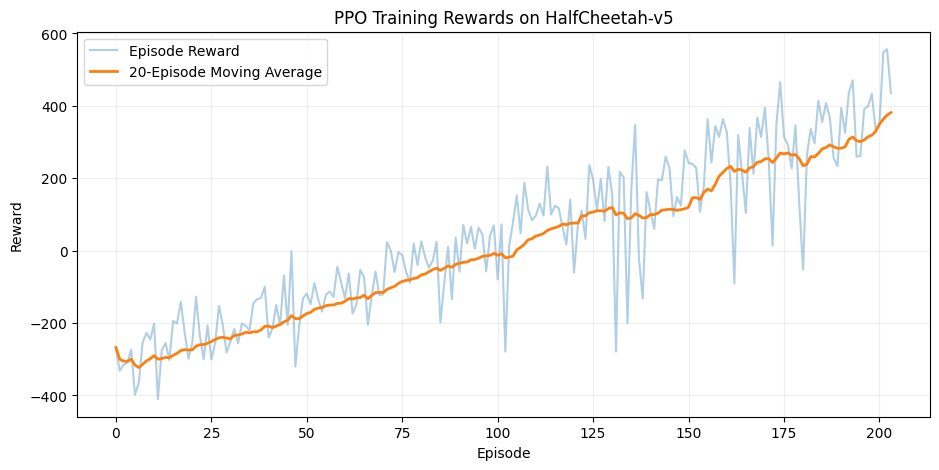

In [16]:
if len(episode_rewards) > 0:

    reward_series = pd.Series(episode_rewards)

    moving_average = reward_series.rolling(
        window=20,
        min_periods=1
    ).mean()

    plt.figure(figsize=(11, 5))

    plt.plot(
        episode_rewards,
        alpha=0.35,
        label="Episode Reward"
    )

    plt.plot(
        moving_average,
        linewidth=2,
        label="20-Episode Moving Average"
    )

    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title("PPO Training Rewards on HalfCheetah-v5")
    plt.legend()
    plt.grid(alpha=0.2)

    plt.show()

# **Policy Loss**

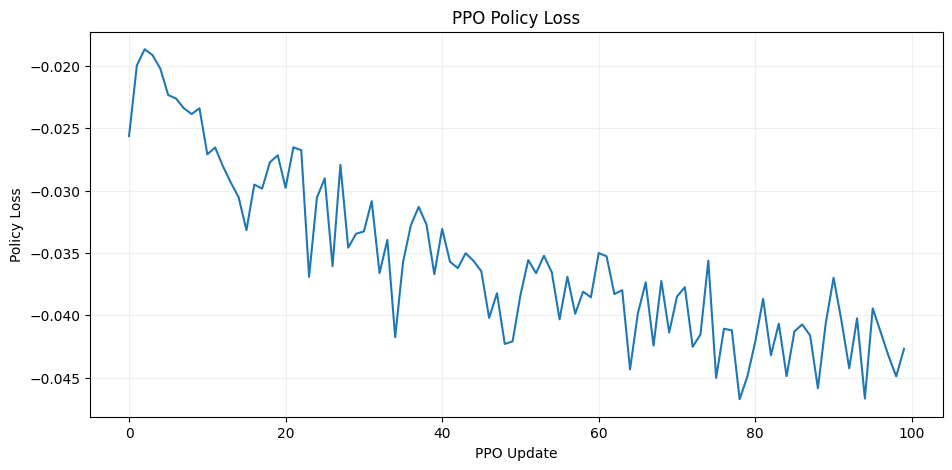

In [17]:
plt.figure(figsize=(11, 5))

plt.plot(policy_loss_history)

plt.xlabel("PPO Update")
plt.ylabel("Policy Loss")
plt.title("PPO Policy Loss")
plt.grid(alpha=0.2)

plt.show()

# **Value Loss**

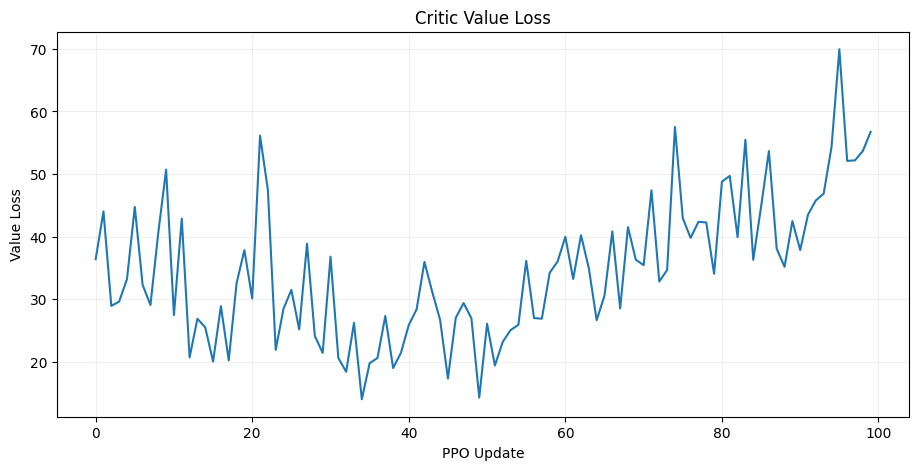

In [18]:
plt.figure(figsize=(11, 5))

plt.plot(value_loss_history)

plt.xlabel("PPO Update")
plt.ylabel("Value Loss")
plt.title("Critic Value Loss")
plt.grid(alpha=0.2)

plt.show()

# **Entropy**

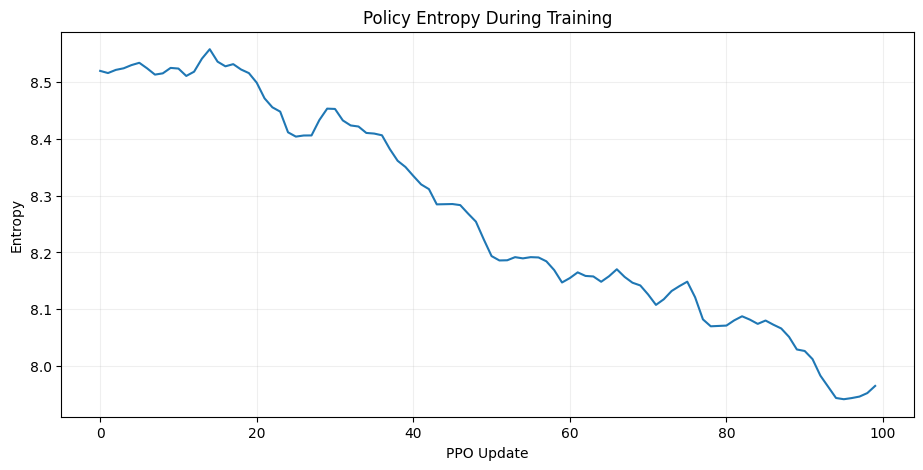

In [19]:
plt.figure(figsize=(11, 5))

plt.plot(entropy_history)

plt.xlabel("PPO Update")
plt.ylabel("Entropy")
plt.title("Policy Entropy During Training")
plt.grid(alpha=0.2)

plt.show()

# **Update Stability**

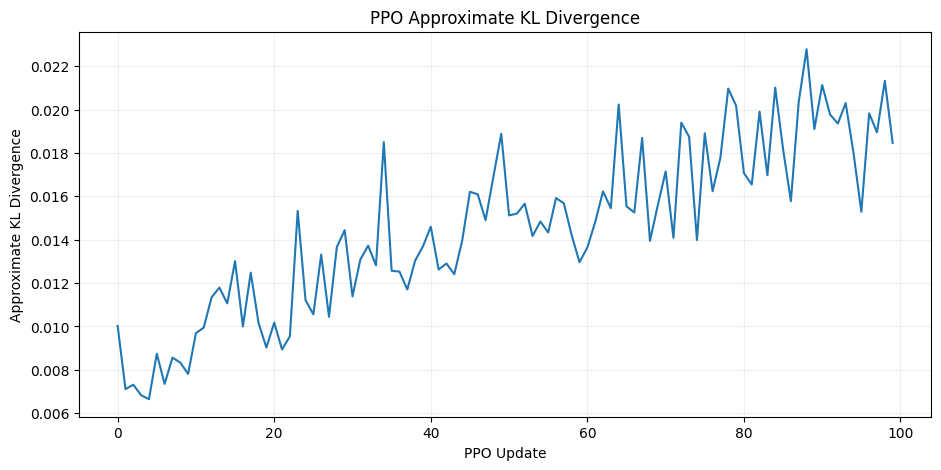

In [20]:
plt.figure(figsize=(11, 5))

plt.plot(approx_kl_history)

plt.xlabel("PPO Update")
plt.ylabel("Approximate KL Divergence")
plt.title("PPO Approximate KL Divergence")
plt.grid(alpha=0.2)

plt.show()

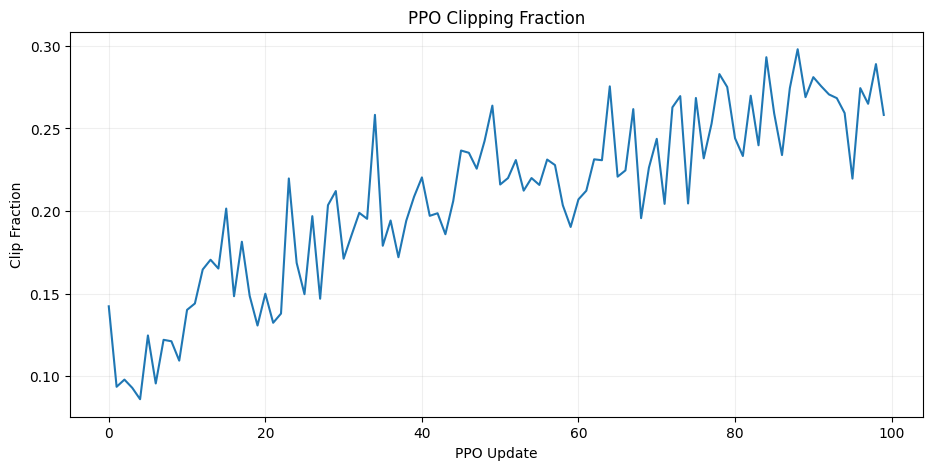

In [21]:
plt.figure(figsize=(11, 5))

plt.plot(clip_fraction_history)

plt.xlabel("PPO Update")
plt.ylabel("Clip Fraction")
plt.title("PPO Clipping Fraction")
plt.grid(alpha=0.2)

plt.show()

# **Final Evaluation**

In [22]:
def evaluate_agent(model, env_name=ENV_NAME, episodes=10, seed=123):
    eval_env = gym.make(env_name)

    rewards = []

    model.eval()

    for episode in range(episodes):
        state, info = eval_env.reset(seed=seed + episode)

        done = False
        total_reward = 0.0

        while not done:
            state_tensor = torch.tensor(
                state,
                dtype=torch.float32,
                device=device
            ).unsqueeze(0)

            with torch.no_grad():
                dist, _ = model.get_distribution_and_value(state_tensor)

                raw_action = dist.mean

                env_action = squash_action(raw_action)

            action_np = env_action.squeeze(0).cpu().numpy()

            state, reward, terminated, truncated, info = eval_env.step(action_np)

            done = terminated or truncated

            total_reward += reward

        rewards.append(total_reward)

        print(
            f"Evaluation Episode {episode + 1}: "
            f"{total_reward:.2f}"
        )

    eval_env.close()

    model.train()

    return rewards


evaluation_rewards = evaluate_agent(
    model,
    episodes=10
)

Evaluation Episode 1: 829.92
Evaluation Episode 2: 813.80
Evaluation Episode 3: 763.27
Evaluation Episode 4: 758.90
Evaluation Episode 5: 736.09
Evaluation Episode 6: 861.02
Evaluation Episode 7: 814.82
Evaluation Episode 8: 770.87
Evaluation Episode 9: 746.88
Evaluation Episode 10: -39.17


# **Result**

In [27]:
print("\n===== PPO TRAINING RESULTS =====\n")

print("Environment:", ENV_NAME)
print("Total Environment Steps:", total_steps)
print("Completed Training Episodes:", len(episode_rewards))

if len(episode_rewards) > 0:
    print(
        "Average Training Reward:",
        round(float(np.mean(episode_rewards)), 2)
    )

    print(
        "Best Training Reward:",
        round(float(np.max(episode_rewards)), 2)
    )

    final_window = min(20, len(episode_rewards))

    print(
        f"Final {final_window}-Episode Average:",
        round(float(np.mean(episode_rewards[-final_window:])), 2)
    )

print("\n===== EVALUATION RESULTS =====\n")


print(
    "Evaluation Mean Reward:",
    round(float(np.mean(evaluation_rewards)), 2)
)

print(
    "Evaluation Maximum Reward:",
    round(float(np.max(evaluation_rewards)), 2)
)

print(
    "Evaluation Minimum Reward:",
    round(float(np.min(evaluation_rewards)), 2)
)


===== PPO TRAINING RESULTS =====

Environment: HalfCheetah-v5
Total Environment Steps: 204800
Completed Training Episodes: 204
Average Training Reward: 34.02
Best Training Reward: 556.27
Final 20-Episode Average: 381.18

===== EVALUATION RESULTS =====

Evaluation Mean Reward: 705.64
Evaluation Maximum Reward: 861.02
Evaluation Minimum Reward: -39.17
